In [4]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------------
# 1. Load data
# -------------------------------
train_df = pd.read_csv('Binarylabel_Train.csv')
val_df = pd.read_csv('Binarylabel_Val.csv')
test_df = pd.read_csv('Binarylabel_Test - Competition.csv')

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nClass distribution in training set:")
print(train_df['label'].value_counts().sort_index())

# -------------------------------
# 2. Text preprocessing
# -------------------------------
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'<.*?>', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return ''

train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text'] = val_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

X_train_raw = train_df['clean_text'].values
y_train = train_df['label'].values
X_val_raw = val_df['clean_text'].values
y_val = val_df['label'].values
X_test_raw = test_df['clean_text'].values

# -------------------------------
# 3. Feature extraction for ML models (TF-IDF)
# -------------------------------
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_val_tfidf = tfidf.transform(X_val_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print(f"TF-IDF shape: {X_train_tfidf.shape}")

# -------------------------------
# 4. Handle class imbalance with SMOTE (for ML models)
# -------------------------------
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)
print("After SMOTE, class distribution:")
unique, counts = np.unique(y_train_smote, return_counts=True)
print(dict(zip(unique, counts)))

# -------------------------------
# 5. Compute class weights for DL model
# -------------------------------
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# -------------------------------
# 6. DL preprocessing (tokenization and padding)
# -------------------------------
MAX_NB_WORDS = 10000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 100

tokenizer = Tokenizer(num_words=MAX_NB_WORDS)
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_val_seq = tokenizer.texts_to_sequences(X_val_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH)
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH)

# For DL, binary classification uses a single output neuron with sigmoid
y_train_dl = y_train
y_val_dl = y_val

# -------------------------------
# 7. Define evaluation function
# -------------------------------
def evaluate_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    # For DL, predictions may be probabilities, convert to binary
    if len(y_pred.shape) > 1 and y_pred.shape[1] == 1:
        y_pred = (y_pred > 0.5).astype(int).flatten()
    elif len(y_pred.shape) > 1 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='macro')  # macro is same as binary for two classes
    cm = confusion_matrix(y_val, y_pred)
    print(f"\n{model_name} - Validation Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
    print(classification_report(y_val, y_pred))
    return f1, cm, y_pred

# -------------------------------
# 8. Train and evaluate models
# -------------------------------
results = {}

# 8.1 Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_smote, y_train_smote)
f1, cm, _ = evaluate_model(lr, X_val_tfidf, y_val, "Logistic Regression")
results['Logistic Regression'] = {'f1': f1, 'cm': cm, 'model': lr, 'type': 'tfidf'}

# 8.2 Linear SVM
svm = LinearSVC(class_weight='balanced', max_iter=2000)
svm.fit(X_train_smote, y_train_smote)
f1, cm, _ = evaluate_model(svm, X_val_tfidf, y_val, "Linear SVM")
results['Linear SVM'] = {'f1': f1, 'cm': cm, 'model': svm, 'type': 'tfidf'}

# 8.3 Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_smote, y_train_smote)
f1, cm, _ = evaluate_model(rf, X_val_tfidf, y_val, "Random Forest")
results['Random Forest'] = {'f1': f1, 'cm': cm, 'model': rf, 'type': 'tfidf'}

# 8.4 XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, objective='binary:logistic', random_state=42)
xgb.fit(X_train_smote, y_train_smote)
f1, cm, _ = evaluate_model(xgb, X_val_tfidf, y_val, "XGBoost")
results['XGBoost'] = {'f1': f1, 'cm': cm, 'model': xgb, 'type': 'tfidf'}

# 8.5 LSTM (Deep Learning)
def build_lstm_model():
    model = Sequential()
    model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH))
    model.add(Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

lstm_model = build_lstm_model()
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lstm_model.fit(X_train_pad, y_train_dl,
               validation_data=(X_val_pad, y_val_dl),
               epochs=10, batch_size=32,
               class_weight=class_weight_dict,
               callbacks=[early_stop], verbose=1)

y_pred_lstm = (lstm_model.predict(X_val_pad) > 0.5).astype(int).flatten()
f1_lstm = f1_score(y_val, y_pred_lstm, average='macro')
cm_lstm = confusion_matrix(y_val, y_pred_lstm)
print(f"\nLSTM - Validation Macro F1: {f1_lstm:.4f}")
print(classification_report(y_val, y_pred_lstm))
results['LSTM'] = {'f1': f1_lstm, 'cm': cm_lstm, 'model': lstm_model, 'type': 'dl'}

# -------------------------------
# 9. Select top 3 models based on Macro F1
# -------------------------------
sorted_models = sorted(results.items(), key=lambda x: x[1]['f1'], reverse=True)
top3 = sorted_models[:3]
print("\nTop 3 Models:")
for name, data in top3:
    print(f"{name}: Macro F1 = {data['f1']:.4f}")

# -------------------------------
# 10. Generate predictions for test set using top 3 models (CORRECTED)
# -------------------------------
def predict_test(model, model_type, X_test_raw_data, tfidf_vectorizer=None, tokenizer_obj=None):
    if model_type == 'tfidf':
        X_test_transformed = tfidf_vectorizer.transform(X_test_raw_data)
        preds = model.predict(X_test_transformed)
        if len(preds.shape) > 1 and preds.shape[1] == 1:
            preds = (preds > 0.5).astype(int).flatten()
        elif len(preds.shape) > 1:
            preds = np.argmax(preds, axis=1)
    else:  # dl
        seqs = tokenizer_obj.texts_to_sequences(X_test_raw_data)
        padded = pad_sequences(seqs, maxlen=MAX_SEQUENCE_LENGTH)
        preds = (model.predict(padded) > 0.5).astype(int).flatten()
    return preds

for attempt, (name, data) in enumerate(top3, start=1):
    model = data['model']
    model_type = data['type']
    if model_type == 'tfidf':
        test_preds = predict_test(model, model_type, X_test_raw, tfidf_vectorizer=tfidf)
    else:
        test_preds = predict_test(model, model_type, X_test_raw, tokenizer_obj=tokenizer)

    # ✅ CORRECTED: Keep original test_df and only update 'label' column
    submission = test_df.copy()
    submission['label'] = test_preds
    filename = f"Group # 08__Binarylabel_Test - Competition__Attempt {attempt}.csv"
    submission.to_csv(filename, index=False)
    print(f"Saved predictions for {name} to {filename}")
print("\nAll done!")

Train shape: (1957, 3)
Val shape: (653, 3)
Test shape: (653, 3)

Class distribution in training set:
label
0    1551
1     406
Name: count, dtype: int64
TF-IDF shape: (1957, 5000)
After SMOTE, class distribution:
{np.int64(0): np.int64(1551), np.int64(1): np.int64(1551)}
Class weights: {0: np.float64(0.630883301096067), 1: np.float64(2.4100985221674875)}

Logistic Regression - Validation Accuracy: 0.7810, Macro F1: 0.6996
              precision    recall  f1-score   support

           0       0.89      0.82      0.86       518
           1       0.48      0.63      0.54       135

    accuracy                           0.78       653
   macro avg       0.69      0.73      0.70       653
weighted avg       0.81      0.78      0.79       653


Linear SVM - Validation Accuracy: 0.7902, Macro F1: 0.6878
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       518
           1       0.49      0.53      0.51       135

    accuracy           

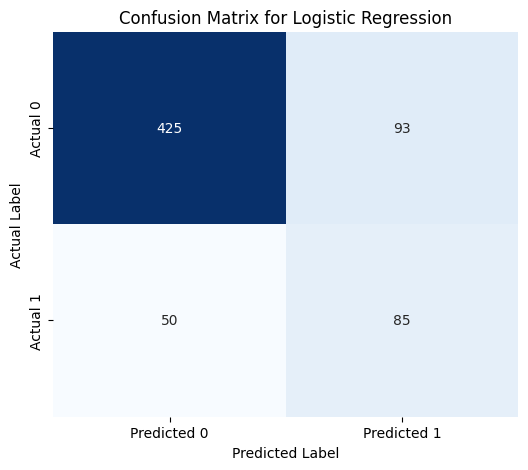

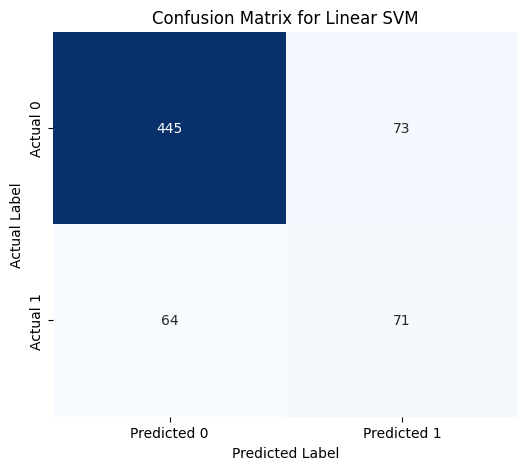

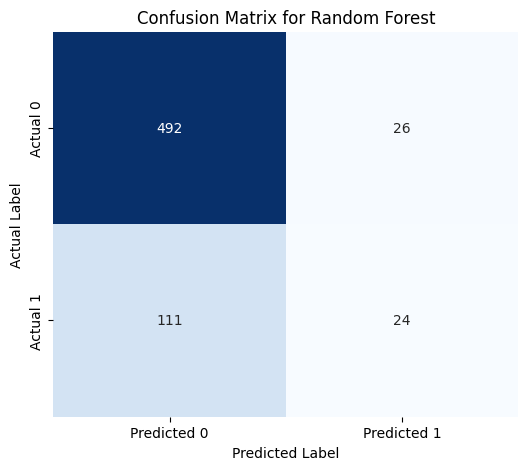

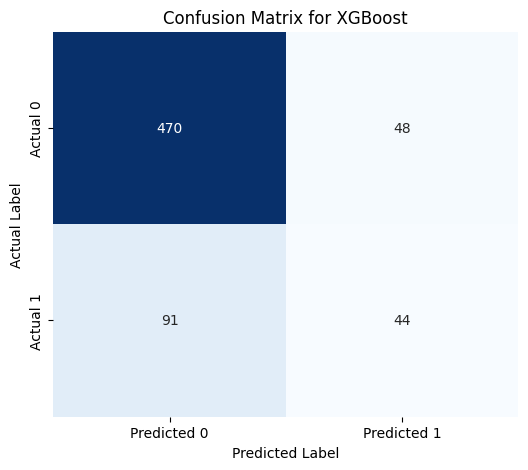

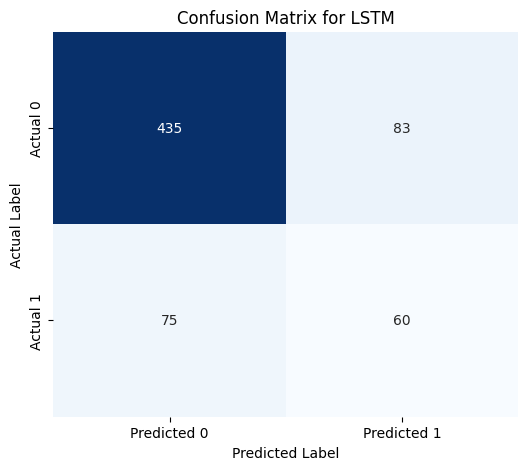

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, data in results.items():
    cm = data['cm']
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix for {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [ ]:
# -------------------------------
# 10. Generate predictions for test set using top 3 models (CORRECTED)
# -------------------------------
def predict_test(model, model_type, X_test_raw_data, tfidf_vectorizer=None, tokenizer_obj=None):
    if model_type == 'tfidf':
        X_test_transformed = tfidf_vectorizer.transform(X_test_raw_data)
        preds = model.predict(X_test_transformed)
        if len(preds.shape) > 1 and preds.shape[1] == 1:
            preds = (preds > 0.5).astype(int).flatten()
        elif len(preds.shape) > 1:
            preds = np.argmax(preds, axis=1)
    else:  # dl
        seqs = tokenizer_obj.texts_to_sequences(X_test_raw_data)
        padded = pad_sequences(seqs, maxlen=MAX_SEQUENCE_LENGTH)
        preds = (model.predict(padded) > 0.5).astype(int).flatten()
    return preds

for attempt, (name, data) in enumerate(top3, start=1):
    model = data['model']
    model_type = data['type']
    if model_type == 'tfidf':
        test_preds = predict_test(model, model_type, X_test_raw, tfidf_vectorizer=tfidf)
    else:
        test_preds = predict_test(model, model_type, X_test_raw, tokenizer_obj=tokenizer)

    # ✅ CORRECTED: Keep original test_df and only update 'label' column
    submission = test_df.copy()
    submission['label'] = test_preds
    filename = f"Group # 08__Binarylabel_Test - Competition__Attempt {attempt}.csv"
    submission.to_csv(filename, index=False)
    print(f"Saved predictions for {name} to {filename}")